# Домашнє завдання: Прогнозування орендної плати за житло

## Мета завдання
Застосувати знання з лекції для побудови моделі лінійної регресії, що прогнозує орендну плату за житло в Індії. Ви пройдете весь цикл вирішення задачі машинного навчання: від дослідницького аналізу до оцінки якості моделі.

## Опис датасету
**House Rent Prediction Dataset** містить інформацію про 4700+ оголошень про оренду житла в Індії з такими параметрами:
- **BHK**: Кількість спалень, залів, кухонь
- **Rent**: Орендна плата (цільова змінна)
- **Size**: Площа в квадратних футах
- **Floor**: Поверх та загальна кількість поверхів
- **Area Type**: Тип розрахунку площі
- **Area Locality**: Район
- **City**: Місто
- **Furnishing Status**: Стан меблювання
- **Tenant Preferred**: Тип орендаря
- **Bathroom**: Кількість ванних кімнат
- **Point of Contact**: Контактна особа

---

## Завдання 1: Завантаження та перший огляд даних (1 бал)

**Що потрібно зробити:**
1. Завантажте дані з файлу `House_Rent_Dataset.csv`
2. Виведіть розмір датасету
3. Покажіть перші 5 рядків
4. Виведіть загальну інформацію про дані (включно з типами даних та кількістю значень)


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/drive/MyDrive/HW_ML/House_Rent_Dataset.csv')

print("Розмір датасету (рядки, стовпці):", df.shape)

print("\nПерші 5 рядків датасету:")
print(df.head())

print("\nІнформація про датасет (типи даних та кількість значень):")
df.info()

Розмір датасету (рядки, стовпці): (4746, 12)

Перші 5 рядків датасету:
    Posted On  BHK   Rent  Size            Floor    Area Type  \
0  2022-05-18    2  10000  1100  Ground out of 2   Super Area   
1  2022-05-13    2  20000   800       1 out of 3   Super Area   
2  2022-05-16    2  17000  1000       1 out of 3   Super Area   
3  2022-07-04    2  10000   800       1 out of 2   Super Area   
4  2022-05-09    2   7500   850       1 out of 2  Carpet Area   

              Area Locality     City Furnishing Status  Tenant Preferred  \
0                    Bandel  Kolkata       Unfurnished  Bachelors/Family   
1  Phool Bagan, Kankurgachi  Kolkata    Semi-Furnished  Bachelors/Family   
2   Salt Lake City Sector 2  Kolkata    Semi-Furnished  Bachelors/Family   
3               Dumdum Park  Kolkata       Unfurnished  Bachelors/Family   
4             South Dum Dum  Kolkata       Unfurnished         Bachelors   

   Bathroom Point of Contact  
0         2    Contact Owner  
1         1    Cont

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Завдання 2: Дослідницький аналіз даних (EDA) (5 балів)

**Що потрібно зробити:**
1. **Аналіз пропущених значень.** Перевірте наявність і відсоток пропущених значень у кожній колонці
2. **Базова статистика.** Обчисліть базову статистику (середнє, квартилі, стандартне відхилення) для числових змінних.
3. **Аналіз цільової змінної.** Побудуйте гістограму розподілу цільової змінної (Rent)
4. **Робота з викидами.** Знайдіть та видаліть викиди в цільовій змінній (якщо є). Визначити викиди можна будь-яким зрозумілим для вас способом, як варіант - таким, що використовується в побудові box-plot (https://en.wikipedia.org/wiki/Box_plot#Example_with_outliers).
5. **Аналіз категоріальних змінних.** Виведіть кількість унікальних значень для кожної з категоріальних колонок.


1. АНАЛІЗ ПРОПУЩЕНИХ ЗНАЧЕНЬ
Empty DataFrame
Columns: [Кількість пропусків, Відсоток]
Index: []

Загальна кількість пропусків: 0

2. БАЗОВА СТАТИСТИКА ДЛЯ ЧИСЛОВИХ ЗМІННИХ
Числові колонки: ['BHK', 'Rent', 'Size', 'Bathroom']
               BHK          Rent         Size     Bathroom
count  4746.000000  4.746000e+03  4746.000000  4746.000000
mean      2.083860  3.499345e+04   967.490729     1.965866
std       0.832256  7.810641e+04   634.202328     0.884532
min       1.000000  1.200000e+03    10.000000     1.000000
25%       2.000000  1.000000e+04   550.000000     1.000000
50%       2.000000  1.600000e+04   850.000000     2.000000
75%       3.000000  3.300000e+04  1200.000000     2.000000
max       6.000000  3.500000e+06  8000.000000    10.000000

3. ГІСТОГРАМА РОЗПОДІЛУ ЦІЛЬОВОЇ ЗМІННОЇ (Rent)
Статистика Rent:
  Середнє значення: 34993.45
  Медіана: 16000.00
  Мінімум: 1200
  Максимум: 3500000
  Стандартне відхилення: 78106.41

4. ВИДАЛЕННЯ ВИКИДІВ У ЦІЛЬОВІЙ ЗМІННІ
Нижня межа (Q1 - 1.

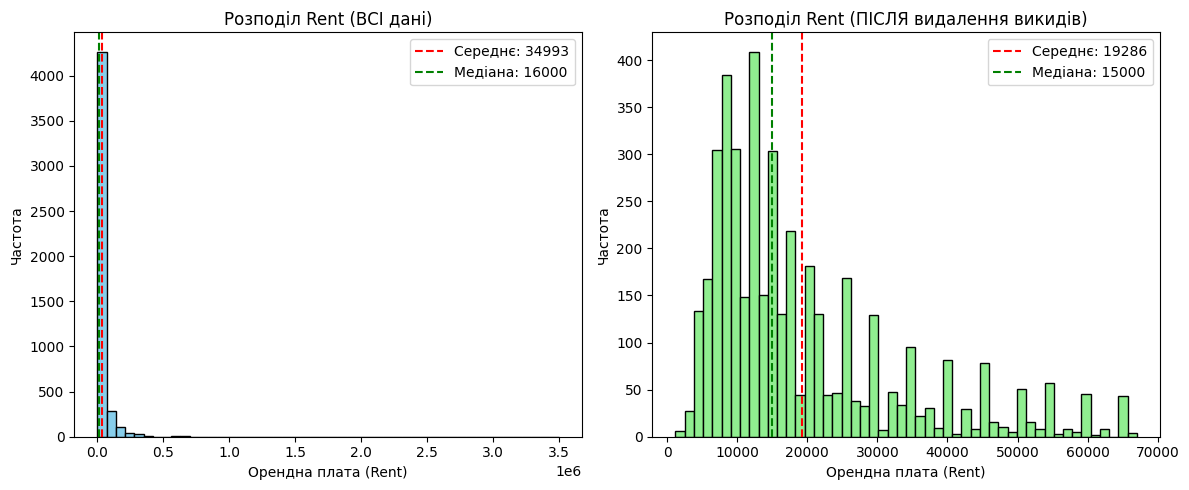

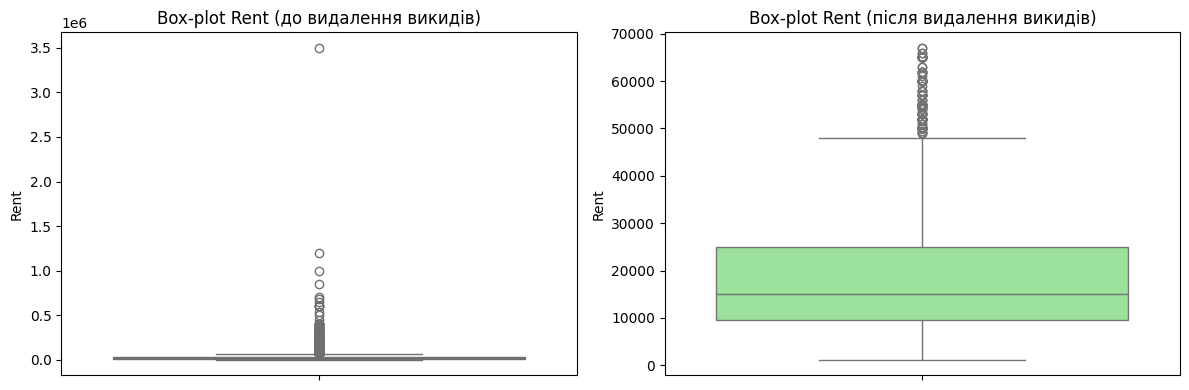


5. АНАЛІЗ КАТЕГОРІАЛЬНИХ ЗМІННИХ
Категоріальні колонки: ['Posted On', 'Floor', 'Area Type', 'Area Locality', 'City', 'Furnishing Status', 'Tenant Preferred', 'Point of Contact']

Posted On: 81 унікальних значень
Floor: 480 унікальних значень
Area Type: 3 унікальних значень
  Значення: ['Super Area' 'Carpet Area' 'Built Area']
Area Locality: 2235 унікальних значень
City: 6 унікальних значень
  Значення: ['Kolkata' 'Mumbai' 'Bangalore' 'Delhi' 'Chennai' 'Hyderabad']
Furnishing Status: 3 унікальних значень
  Значення: ['Unfurnished' 'Semi-Furnished' 'Furnished']
Tenant Preferred: 3 унікальних значень
  Значення: ['Bachelors/Family' 'Bachelors' 'Family']
Point of Contact: 3 унікальних значень
  Значення: ['Contact Owner' 'Contact Agent' 'Contact Builder']


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1
print("="*50)
print("1. АНАЛІЗ ПРОПУЩЕНИХ ЗНАЧЕНЬ")
print("="*50)

missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Кількість пропусків': missing,
    'Відсоток': missing_percent
})
print(missing_df[missing_df['Кількість пропусків'] > 0])
print(f"\nЗагальна кількість пропусків: {df.isnull().sum().sum()}")

# 2
print("\n" + "="*50)
print("2. БАЗОВА СТАТИСТИКА ДЛЯ ЧИСЛОВИХ ЗМІННИХ")
print("="*50)

numeric_cols = df.select_dtypes(include=[np.number]).columns
print(f"Числові колонки: {list(numeric_cols)}")
print(df[numeric_cols].describe())

# 3
print("\n" + "="*50)
print("3. ГІСТОГРАМА РОЗПОДІЛУ ЦІЛЬОВОЇ ЗМІННОЇ (Rent)")
print("="*50)

plt.figure(figsize=(12, 5))

# Гістограма до обробки викидів
plt.subplot(1, 2, 1)
plt.hist(df['Rent'], bins=50, color='skyblue', edgecolor='black')
plt.xlabel('Орендна плата (Rent)')
plt.ylabel('Частота')
plt.title('Розподіл Rent (ВСІ дані)')
plt.axvline(df['Rent'].mean(), color='red', linestyle='--', label=f'Середнє: {df["Rent"].mean():.0f}')
plt.axvline(df['Rent'].median(), color='green', linestyle='--', label=f'Медіана: {df["Rent"].median():.0f}')
plt.legend()

print(f"Статистика Rent:")
print(f"  Середнє значення: {df['Rent'].mean():.2f}")
print(f"  Медіана: {df['Rent'].median():.2f}")
print(f"  Мінімум: {df['Rent'].min()}")
print(f"  Максимум: {df['Rent'].max()}")
print(f"  Стандартне відхилення: {df['Rent'].std():.2f}")

# 4
print("\n" + "="*50)
print("4. ВИДАЛЕННЯ ВИКИДІВ У ЦІЛЬОВІЙ ЗМІННІ")
print("="*50)

# Метод IQR (box-plot rule)
Q1 = df['Rent'].quantile(0.25)
Q3 = df['Rent'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Rent'] < lower_bound) | (df['Rent'] > upper_bound)]
print(f"Нижня межа (Q1 - 1.5*IQR): {lower_bound:.2f}")
print(f"Верхня межа (Q3 + 1.5*IQR): {upper_bound:.2f}")
print(f"Кількість викидів у Rent: {len(outliers)}")
print(f"Відсоток викидів: {len(outliers)/len(df)*100:.2f}%")

# Видаляємо викиди
df_clean = df[(df['Rent'] >= lower_bound) & (df['Rent'] <= upper_bound)].copy()
print(f"\nРозмір датасету ПІСЛЯ видалення викидів: {df_clean.shape}")

# Гістограма після видалення викидів
plt.subplot(1, 2, 2)
plt.hist(df_clean['Rent'], bins=50, color='lightgreen', edgecolor='black')
plt.xlabel('Орендна плата (Rent)')
plt.ylabel('Частота')
plt.title('Розподіл Rent (ПІСЛЯ видалення викидів)')
plt.axvline(df_clean['Rent'].mean(), color='red', linestyle='--', label=f'Середнє: {df_clean["Rent"].mean():.0f}')
plt.axvline(df_clean['Rent'].median(), color='green', linestyle='--', label=f'Медіана: {df_clean["Rent"].median():.0f}')
plt.legend()

plt.tight_layout()
plt.show()

# Box-plot до/після
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(y=df['Rent'], ax=axes[0], color='skyblue')
axes[0].set_title('Box-plot Rent (до видалення викидів)')
axes[0].set_ylabel('Rent')
sns.boxplot(y=df_clean['Rent'], ax=axes[1], color='lightgreen')
axes[1].set_title('Box-plot Rent (після видалення викидів)')
axes[1].set_ylabel('Rent')
plt.tight_layout()
plt.show()

# 5
print("\n" + "="*50)
print("5. АНАЛІЗ КАТЕГОРІАЛЬНИХ ЗМІННИХ")
print("="*50)

categorical_cols = df.select_dtypes(include=['object']).columns
print(f"Категоріальні колонки: {list(categorical_cols)}\n")

for col in categorical_cols:
    unique_count = df[col].nunique()
    print(f"{col}: {unique_count} унікальних значень")
    if unique_count <= 10:  # Якщо небагато значень - покажемо їх
        print(f"  Значення: {df[col].unique()}")


## Завдання 3: Аналіз кореляцій та взаємозв'язків (3 бали)

**Що потрібно зробити:**
1. Обчисліть матрицю кореляцій для числових змінних
2. Візуалізуйте кореляційну матрицю за допомогою heatmap
3. Побудуйте scatter plot між Size та Rent
4. Проаналізуйте взаємозв'язок між BHK та Rent за допомогою boxplot (який розподіл плати для різних значень BHK)


1. МАТРИЦЯ КОРЕЛЯЦІЙ ДЛЯ ЧИСЛОВИХ ЗМІННИХ
Числові змінні: ['BHK', 'Rent', 'Size', 'Bathroom']

Матриця кореляцій (коефіцієнт Пірсона):
            BHK   Rent   Size  Bathroom
BHK       1.000  0.401  0.698     0.748
Rent      0.401  1.000  0.394     0.507
Size      0.698  0.394  1.000     0.681
Bathroom  0.748  0.507  0.681     1.000

Найсильніші кореляції з цільовою змінною Rent:
Rent        1.000
Bathroom    0.507
BHK         0.401
Size        0.394
Name: Rent, dtype: float64


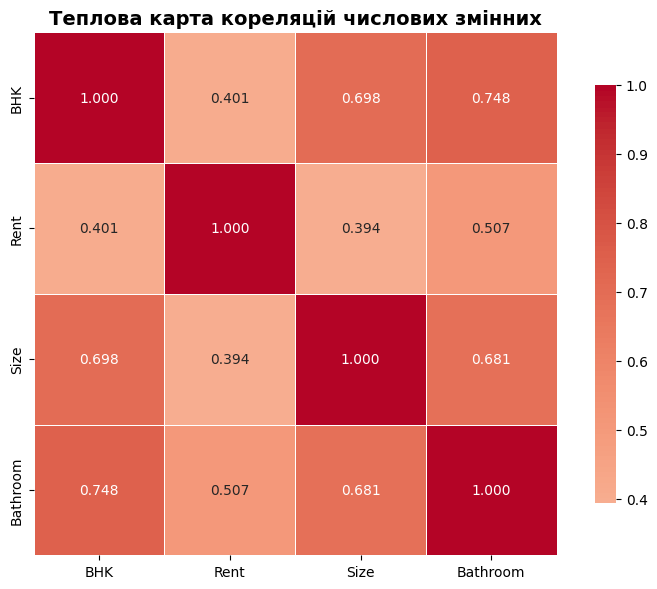


3. SCATTER PLOT: SIZE vs RENT


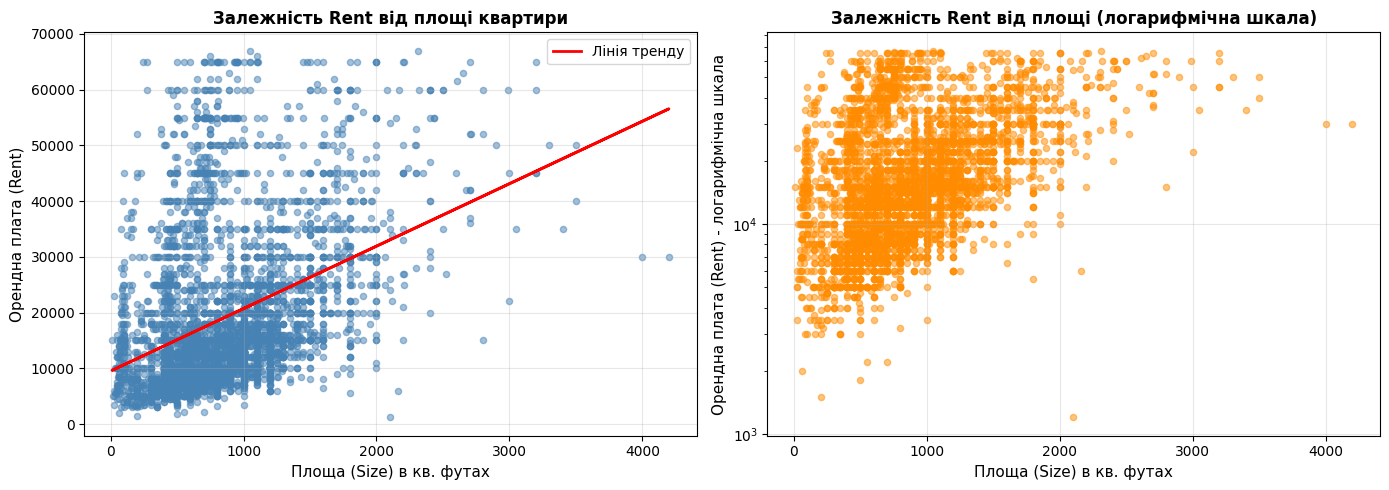

Коефіцієнт кореляції Пірсона між Size та Rent: 0.394
Інтерпретація: Помірна кореляція

4. BOXPLOT: BHK vs RENT
Унікальні значення BHK: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]

Статистика орендної плати для різної кількості BHK:
     count      mean   median       std
BHK                                    
1     1156  13413.04   9000.0  10788.36
2     2165  18140.83  14000.0  12573.80
3      838  29014.37  25000.0  14379.02
4       56  35560.73  35000.0  16424.82
5        5  38500.00  45000.0  13647.34
6        6  37500.00  32500.0  18371.17


/tmp/ipykernel_7734/1337308556.py:102: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='BHK', y='Rent', palette='Set2')
/tmp/ipykernel_7734/1337308556.py:110: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='BHK', y='Rent', palette='Set3')


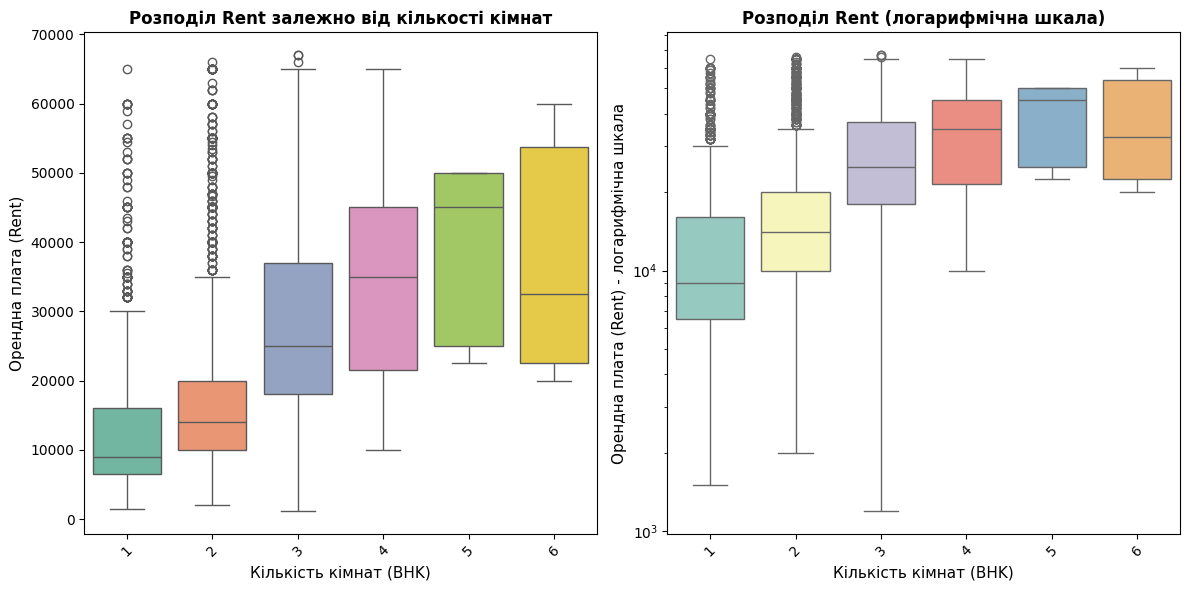

/tmp/ipykernel_7734/1337308556.py:122: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_clean, x='BHK', y='Rent', palette='muted')


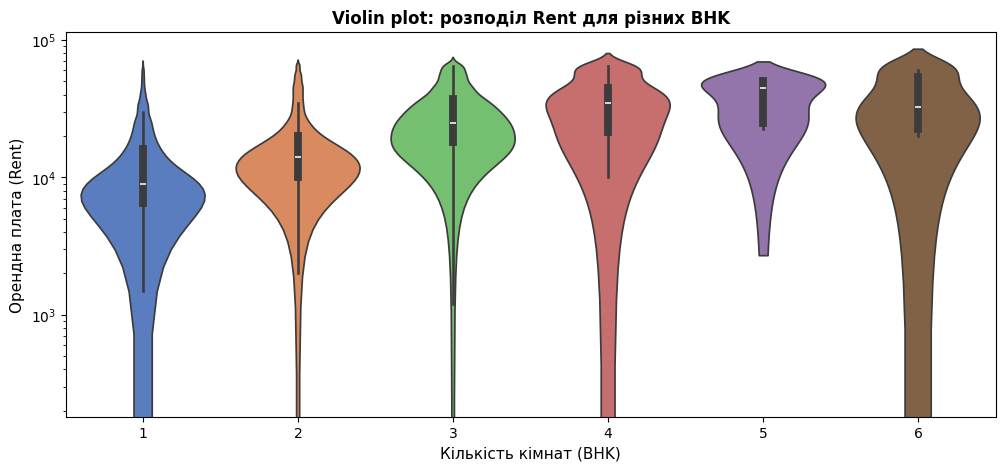

In [ ]:
Q1 = df['Rent'].quantile(0.25)
Q3 = df['Rent'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df_clean = df[(df['Rent'] >= lower_bound) & (df['Rent'] <= upper_bound)].copy()

# 1
print("="*60)
print("1. МАТРИЦЯ КОРЕЛЯЦІЙ ДЛЯ ЧИСЛОВИХ ЗМІННИХ")
print("="*60)

numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
print(f"Числові змінні: {list(numeric_cols)}")
print("\nМатриця кореляцій (коефіцієнт Пірсона):")
correlation_matrix = df_clean[numeric_cols].corr()
print(correlation_matrix.round(3))

# Інтерпретація найсильніших кореляцій
print("\nНайсильніші кореляції з цільовою змінною Rent:")
rent_corr = correlation_matrix['Rent'].sort_values(ascending=False)
print(rent_corr.round(3))

# 2
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix,
            annot=True,
            cmap='coolwarm',
            center=0,
            square=True,
            fmt='.3f',
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})
plt.title('Теплова карта кореляцій числових змінних', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 3
print("\n" + "="*60)
print("3. SCATTER PLOT: SIZE vs RENT")
print("="*60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot (всі дані)
axes[0].scatter(df_clean['Size'], df_clean['Rent'], alpha=0.5, s=20, c='steelblue')
axes[0].set_xlabel('Площа (Size) в кв. футах', fontsize=11)
axes[0].set_ylabel('Орендна плата (Rent)', fontsize=11)
axes[0].set_title('Залежність Rent від площі квартири', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Лінія тренду (поліноміальна регресія 1 ступеня)
from sklearn.linear_model import LinearRegression
X = df_clean[['Size']].values
y = df_clean['Rent'].values
model = LinearRegression()
model.fit(X, y)
axes[0].plot(X, model.predict(X), color='red', linewidth=2, label='Лінія тренду')
axes[0].legend()

# Scatter plot з логарифмічним масштабом для кращої візуалізації
axes[1].scatter(df_clean['Size'], df_clean['Rent'], alpha=0.5, s=20, c='darkorange')
axes[1].set_xlabel('Площа (Size) в кв. футах', fontsize=11)
axes[1].set_ylabel('Орендна плата (Rent) - логарифмічна шкала', fontsize=11)
axes[1].set_title('Залежність Rent від площі (логарифмічна шкала)', fontsize=12, fontweight='bold')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Коефіцієнт кореляції між Size та Rent
size_rent_corr = df_clean['Size'].corr(df_clean['Rent'])
print(f"Коефіцієнт кореляції Пірсона між Size та Rent: {size_rent_corr:.3f}")
print("Інтерпретація: ", end="")
if abs(size_rent_corr) < 0.3:
    print("Слабка кореляція")
elif abs(size_rent_corr) < 0.7:
    print("Помірна кореляція")
else:
    print("Сильна кореляція")

# 4
print("\n" + "="*60)
print("4. BOXPLOT: BHK vs RENT")
print("="*60)

# Перевіряємо унікальні значення BHK
unique_bhk = sorted(df_clean['BHK'].unique())
print(f"Унікальні значення BHK: {unique_bhk}")

# Статистика по кожному BHK
print("\nСтатистика орендної плати для різної кількості BHK:")
bhk_stats = df_clean.groupby('BHK')['Rent'].agg(['count', 'mean', 'median', 'std'])
print(bhk_stats.round(2))

# Побудова boxplot
plt.figure(figsize=(12, 6))

# Основний boxplot
plt.subplot(1, 2, 1)
sns.boxplot(data=df_clean, x='BHK', y='Rent', palette='Set2')
plt.xlabel('Кількість кімнат (BHK)', fontsize=11)
plt.ylabel('Орендна плата (Rent)', fontsize=11)
plt.title('Розподіл Rent залежно від кількості кімнат', fontsize=12, fontweight='bold')
plt.xticks(rotation=45)

# Boxplot з логарифмічною шкалою (для кращого порівняння)
plt.subplot(1, 2, 2)
sns.boxplot(data=df_clean, x='BHK', y='Rent', palette='Set3')
plt.xlabel('Кількість кімнат (BHK)', fontsize=11)
plt.ylabel('Орендна плата (Rent) - логарифмічна шкала', fontsize=11)
plt.title('Розподіл Rent (логарифмічна шкала)', fontsize=12, fontweight='bold')
plt.yscale('log')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Додатковий аналіз: Violin plot (поєднує boxplot і розподіл)
plt.figure(figsize=(12, 5))
sns.violinplot(data=df_clean, x='BHK', y='Rent', palette='muted')
plt.xlabel('Кількість кімнат (BHK)', fontsize=11)
plt.ylabel('Орендна плата (Rent)', fontsize=11)
plt.title('Violin plot: розподіл Rent для різних BHK', fontsize=12, fontweight='bold')
plt.yscale('log')
plt.show()

## Завдання 4: Feature Engineering та підготовка даних (4 бали)

**Що потрібно зробити:**
1. Закодуйте категоріальні змінні за допомогою One-Hot Encoding. Пригадайте, що в лекції ми говорили щодо кодування кат. змінних з великої кількістю різних значень і як працювати з такими випадками. Ви можете закодувати не всі кат. змінні, а лише ті, що вважаєте за потрібні (скажімо ті, що мають відносно небагато різних значень).
2. **Опціонально (по 0.5 бала за кожну доцільну ознаку):** Додайте нові ознаки, обчислені на основі наявних даних, які б на ваш погляд були корисними для моделі
3. Виберіть ознаки для побудови моделі (виключіть непотрібні колонки). Виключити можна, наприклад, ті колонки, які мають категоріальний тип і забагато (більше 20) різних значень. Треба виключити хоча б 1 колонку.
4. Розділіть дані на ознаки (X) та цільову змінну (y)
5. Застосуйте стандартизацію до числових ознак


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

Q1 = df['Rent'].quantile(0.25)
Q3 = df['Rent'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df_clean = df[(df['Rent'] >= lower_bound) & (df['Rent'] <= upper_bound)].copy()

print("="*70)
print("ЗАВДАННЯ 4: FEATURE ENGINEERING ТА ПІДГОТОВКА ДАНИХ")
print("="*70)

# 1
print("\n1. АНАЛІЗ КАТЕГОРІАЛЬНИХ ЗМІННИХ")
print("-"*50)

categorical_cols = df_clean.select_dtypes(include=['object']).columns
print("Категоріальні колонки та кількість унікальних значень:")
for col in categorical_cols:
    n_unique = df_clean[col].nunique()
    print(f"  {col}: {n_unique} унікальних значень")

# 2
print("\n2. ONE-HOT ENCODING")
print("-"*50)

# Вибір категоріальних змінних для кодування (менше 20 унікальних значень)
cols_to_encode = []
cols_to_drop = []

for col in categorical_cols:
    n_unique = df_clean[col].nunique()
    if n_unique <= 20:
        cols_to_encode.append(col)
        print(f"✅ Кодуємо: {col} ({n_unique} категорій)")
    else:
        cols_to_drop.append(col)
        print(f"❌ ВИКЛЮЧАЄМО: {col} ({n_unique} категорій)")

print(f"\nБуде закодовано {len(cols_to_encode)} категоріальних змінних")
print(f"Буде виключено {len(cols_to_drop)} категоріальних змінних")

# Застосування One-Hot Encoding
df_encoded = pd.get_dummies(df_clean, columns=cols_to_encode, drop_first=True)
print(f"\nРозмір датафрейму після One-Hot Encoding: {df_encoded.shape}")

# 3
print("\n3. СТВОРЕННЯ НОВИХ ОЗНАК (FEATURE ENGINEERING)")
print("-"*50)

# Ознака 3.1: Price per sq ft (ціна за квадратний фут)
df_encoded['Price_per_sqft'] = df_encoded['Rent'] / df_encoded['Size']
print("✅ Створено ознаку: Price_per_sqft (ціна за кв.фут)")

# Ознака 3.2: BHK_per_Bathroom (коефіцієнт кімнат до ванних)
df_encoded['BHK_per_Bathroom'] = df_encoded['BHK'] / df_encoded['Bathroom']
print("✅ Створено ознаку: BHK_per_Bathroom (відношення кімнат до ванних)")

# Ознака 3.3: Is_High_Floor (чи квартира на високому поверсі)
# Парсимо колонку Floor: формат "Ground out of 4" або "2 out of 5"
def parse_floor(floor_str):
    try:
        if pd.isna(floor_str):
            return 0
        parts = str(floor_str).split()
        if len(parts) >= 1:
            first_part = parts[0]
            if first_part.lower() == 'ground':
                return 0
            else:
                return int(first_part)
    except:
        return 0
    return 0

df_clean['Floor_Number'] = df_clean['Floor'].apply(parse_floor)
df_clean['Total_Floors'] = df_clean['Floor'].apply(lambda x: int(str(x).split('out of ')[1]) if 'out of' in str(x) else 10)

# Додаємо до закодованого датафрейму
df_encoded['Floor_Number'] = df_clean['Floor_Number']
df_encoded['Total_Floors'] = df_clean['Total_Floors']
df_encoded['Is_High_Floor'] = (df_clean['Floor_Number'] > df_clean['Total_Floors'] / 2).astype(int)
print("✅ Створено ознаку: Is_High_Floor (1 якщо поверх вище середини будинку)")

# Ознака 3.4: Log_Rent (логарифм оренди) - може покращити модель
df_encoded['Log_Rent'] = np.log1p(df_encoded['Rent'])  # log(1+Rent)
print("✅ Створено ознаку: Log_Rent (логарифм орендної плати)")

print("\nСписок нових ознак:")
new_features = ['Price_per_sqft', 'BHK_per_Bathroom', 'Is_High_Floor', 'Log_Rent']
for f in new_features:
    print(f"  - {f}")

# 4
print("\n4. ВИБІР ОЗНАК ДЛЯ МОДЕЛІ")
print("-"*50)

# Колонки, які виключаємо повністю
columns_to_drop = [
    'Area Locality',
    'Floor',
    'Point of Contact',
    'Tenant Preferred',
]

# Видаляємо непотрібні колонки
df_model = df_encoded.drop(columns=columns_to_drop, errors='ignore')
print(f"Виключено колонки: {columns_to_drop}")

# Остаточний список ознак для моделі
print(f"\nФінальна кількість колонок для моделі: {df_model.shape[1]}")
print("\nУсі колонки, які будуть використані:")
for col in df_model.columns:
    print(f"  - {col}")

# 5
print("\n5. РОЗДІЛЕННЯ НА X ТА y")
print("-"*50)

# Цільова змінна (можна вибрати звичайну Rent або Log_Rent)
target_col = 'Rent'  # або 'Log_Rent' для експериментів
y = df_model[target_col]
X = df_model.drop(columns=[target_col, 'Log_Rent'], errors='ignore')

print(f"Цільова змінна: {target_col}")
print(f"Розмір X: {X.shape}")
print(f"Розмір y: {y.shape}")
print(f"Тип даних в X: {X.dtypes.value_counts()}")

# Видаляємо залишкові текстові колонки, якщо є
X = X.select_dtypes(include=[np.number])
print(f"\nПісля очищення тільки числових колонок: X має {X.shape[1]} ознак")

# 6
print("\n6. СТАНДАРТИЗАЦІЯ ЧИСЛОВИХ ОЗНАК")
print("-"*50)

# Розділяємо на тренувальний та тестовий набори СПОЧАТКУ
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Тренувальний набір: X_train {X_train.shape}, y_train {y_train.shape}")
print(f"Тестовий набір: X_test {X_test.shape}, y_test {y_test.shape}")

# Стандартизація (StandardScaler: mean=0, std=1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Перетворюємо назад у DataFrame для зручності
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

print("\n✅ Стандартизацію застосовано!")
print(f"Середнє після стандартизації (train): {X_train_scaled.mean().mean():.2f} (має бути ~0)")
print(f"Стандартне відхилення після стандартизації (train): {X_train_scaled.std().mean():.2f} (має бути ~1)")

# 7
print("\n" + "="*70)
print("ПІДСУМКОВИЙ ЗВІТ ПІДГОТОВКИ ДАНИХ")
print("="*70)

print(f"""
1. Кодування категоріальних змінних:
   - Закодовано: {cols_to_encode}
   - Виключено через багато категорій: {cols_to_drop}

2. Нові ознаки:
   - Price_per_sqft (ціна за квадратний фут)
   - BHK_per_Bathroom (відношення кімнат до ванних)
   - Is_High_Floor (високий поверх)
   - Log_Rent (логарифм оренди - для експериментів)

3. Фінальна кількість ознак: {X_train_scaled.shape[1]}
   З них числових оригінальних: {len([c for c in X.columns if c not in new_features and c not in df_encoded.filter(like='_').columns])}
   З них One-Hot encoded: {len([c for c in X.columns if any(enc in c for enc in cols_to_encode)])}
   З них новостворених: {len([c for c in X.columns if c in new_features and c != 'Log_Rent'])}

4. Розмір даних після підготовки:
   - Тренувальний набір: {X_train_scaled.shape[0]} зразків, {X_train_scaled.shape[1]} ознак
   - Тестовий набір: {X_test_scaled.shape[0]} зразків, {X_test_scaled.shape[1]} ознак
   - Цільова змінна: {target_col}

5. Масштабування: StandardScaler (mean=0, std=1)
""")

# Зберігаємо підготовлені дані для наступного завдання
print("\n💾 Підготовлені дані збережено в змінні: X_train_scaled, X_test_scaled, y_train, y_test")
print("Для наступного завдання (побудова моделі) використовуйте ці дані.")

ЗАВДАННЯ 4: FEATURE ENGINEERING ТА ПІДГОТОВКА ДАНИХ

1. АНАЛІЗ КАТЕГОРІАЛЬНИХ ЗМІННИХ
--------------------------------------------------
Категоріальні колонки та кількість унікальних значень:
  Posted On: 80 унікальних значень
  Floor: 340 унікальних значень
  Area Type: 3 унікальних значень
  Area Locality: 1997 унікальних значень
  City: 6 унікальних значень
  Furnishing Status: 3 унікальних значень
  Tenant Preferred: 3 унікальних значень
  Point of Contact: 3 унікальних значень

2. ONE-HOT ENCODING
--------------------------------------------------
❌ ВИКЛЮЧАЄМО: Posted On (80 категорій)
❌ ВИКЛЮЧАЄМО: Floor (340 категорій)
✅ Кодуємо: Area Type (3 категорій)
❌ ВИКЛЮЧАЄМО: Area Locality (1997 категорій)
✅ Кодуємо: City (6 категорій)
✅ Кодуємо: Furnishing Status (3 категорій)
✅ Кодуємо: Tenant Preferred (3 категорій)
✅ Кодуємо: Point of Contact (3 категорій)

Буде закодовано 5 категоріальних змінних
Буде виключено 3 категоріальних змінних

Розмір датафрейму після One-Hot Encoding: (422

## Завдання 5: Розділення даних та навчання моделі (3 бали)

**Що потрібно зробити:**
1. Розділіть дані на навчальну (80%) та тестову (20%) вибірки.
2. Створіть модель лінійної регресії.
3. Навчіть модель на навчальних даних.
4. Виведіть усі коефіцієнти моделі (ваги) та напишіть, які 2 ознаки найбільше впливають на прогноз.
5. Зробіть прогнози на тренувальній та тестовій вибірках.

## Завдання 6: Оцінка якості моделі (2 бали)

**Що потрібно зробити:**
1. Обчисліть MAE, RMSE та R² для навчальної та тестової вибірок
2. Порівняйте метрики та зробіть висновок про якість моделі
3. Проаналізуйте і дайте висновок, чи є ознаки перенавчання або недонавчання (**Нагадування**: перенавчання - коли модель дуже добре працює на тренувальних даних, але погано на тестових; недонавчання - коли модель погано працює навіть на тренувальних даних)
4. Побудуйте графік розсіювання "реальні vs прогнозовані значення" та зробіть висновок про якість моделі


Перевірка наявності даних...
X_train_scaled shape: (3380, 8)
X_test_scaled shape: (846, 8)
y_train shape: (3380,)
y_test shape: (846,)
ЗАВДАННЯ 5: РОЗДІЛЕННЯ ДАНИХ ТА НАВЧАННЯ МОДЕЛІ

1. ПЕРЕВІРКА РОЗДІЛЕННЯ ДАНИХ
--------------------------------------------------
Тренувальна вибірка (80%): 3380 зразків
Тестова вибірка (20%): 846 зразків
Співвідношення: 80.0% / 20.0%

2. СТВОРЕННЯ ТА НАВЧАННЯ МОДЕЛІ ЛІНІЙНОЇ РЕГРЕСІЇ
--------------------------------------------------
✅ Модель лінійної регресії успішно навчена!

Параметри моделі:
  Intercept (зсув): 19349.55

3. АНАЛІЗ КОЕФІЦІЄНТІВ МОДЕЛІ (ВАГ)
--------------------------------------------------
Всі коефіцієнти моделі (відсортовано за впливом):
  Size                           :  6057.7697  (🔴 ПОЗИТИВНИЙ)
  Price_per_sqft                 :  5571.1593  (🔴 ПОЗИТИВНИЙ)
  Total_Floors                   :  5261.3559  (🔴 ПОЗИТИВНИЙ)
  Bathroom                       :  1097.6144  (🔴 ПОЗИТИВНИЙ)
  BHK_per_Bathroom               :  -718.6947  (🔵 

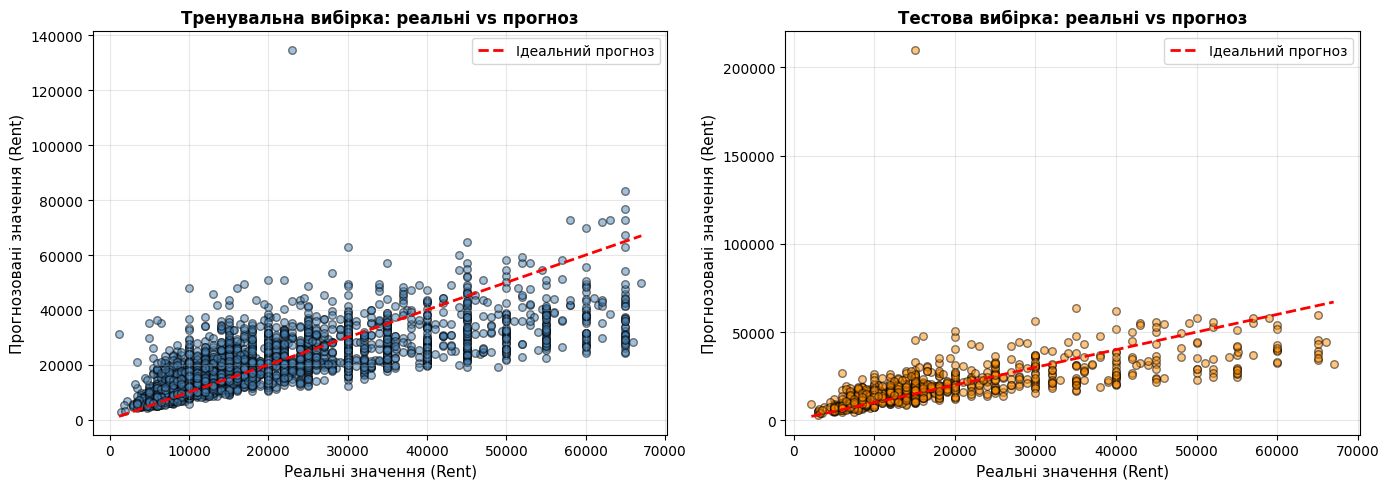

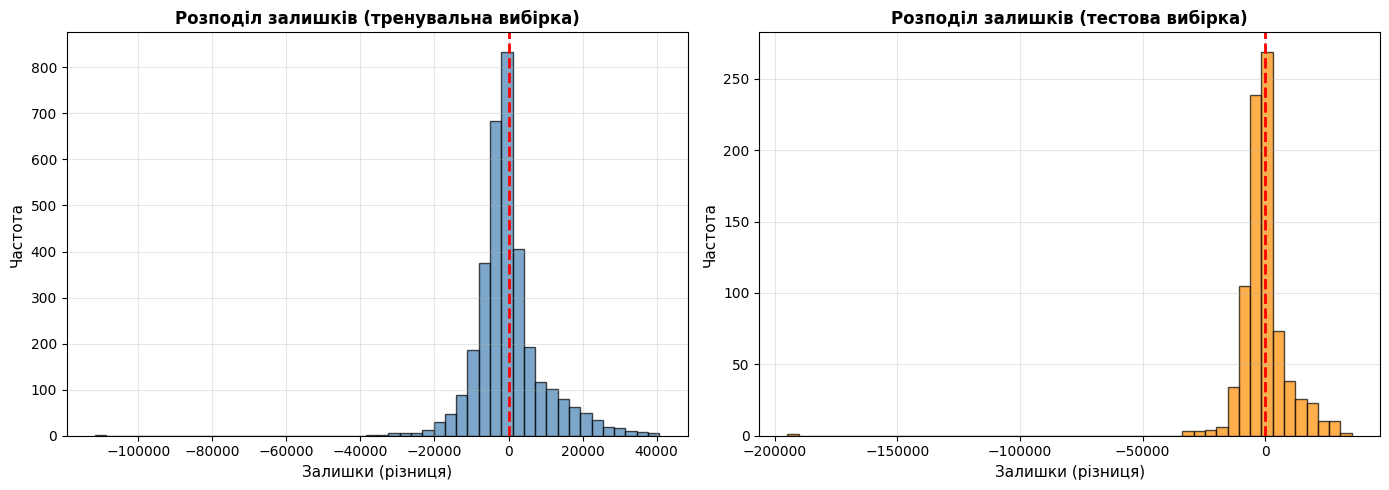


ПІДСУМКОВИЙ ЗВІТ ЗАВДАННЯ 5

1. РОЗДІЛЕННЯ ДАНИХ:
   - Тренувальна вибірка: 3380 зразків (80%)
   - Тестова вибірка: 846 зразків (20%)

2. МОДЕЛЬ ЛІНІЙНОЇ РЕГРЕСІЇ:
   - Intercept (зсув): 19349.55
   - Кількість ознак: 8
   - Формула: Rent = 19349.55 + Σ(коефіцієнт_і × ознака_і)

3. ДВІ НАЙВАЖЛИВІШІ ОЗНАКИ:
   1) Size (коефіцієнт = 6057.7697)
   2) Price_per_sqft (коефіцієнт = 5571.1593)

4. ПРОГНОЗИ:
   - Прогнози виконано для обох вибірок
   - Візуалізацію див. вище


💾 Модель збережено в змінній 'model'
Для наступного завдання (оцінка якості) використовуйте:
   - y_train, y_train_pred (тренувальні)
   - y_test, y_test_pred (тестові)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ========== ВИКОРИСТОВУЄМО ПІДГОТОВЛЕНІ ДАНІ З ЗАВДАННЯ 4 ==========
# Якщо ви щойно виконали Завдання 4, то змінні вже є в пам'яті:
# X_train_scaled, X_test_scaled, y_train, y_test

# Перевіряємо, чи змінні існують (якщо ні - запустіть Завдання 4 спочатку)
try:
    print("Перевірка наявності даних...")
    print(f"X_train_scaled shape: {X_train_scaled.shape}")
    print(f"X_test_scaled shape: {X_test_scaled.shape}")
    print(f"y_train shape: {y_train.shape}")
    print(f"y_test shape: {y_test.shape}")
except NameError:
    print("❌ ПОМИЛКА: Дані не знайдено!")
    print("Будь ласка, спочатку виконайте Завдання 4 для підготовки даних.")
    exit()

print("="*70)
print("ЗАВДАННЯ 5: РОЗДІЛЕННЯ ДАНИХ ТА НАВЧАННЯ МОДЕЛІ")
print("="*70)

# 1
print("\n1. ПЕРЕВІРКА РОЗДІЛЕННЯ ДАНИХ")
print("-"*50)
print(f"Тренувальна вибірка (80%): {X_train_scaled.shape[0]} зразків")
print(f"Тестова вибірка (20%): {X_test_scaled.shape[0]} зразків")
print(f"Співвідношення: {X_train_scaled.shape[0]/len(y_train+y_test)*100:.1f}% / {X_test_scaled.shape[0]/len(y_train+y_test)*100:.1f}%")

# 2
print("\n2. СТВОРЕННЯ ТА НАВЧАННЯ МОДЕЛІ ЛІНІЙНОЇ РЕГРЕСІЇ")
print("-"*50)

# Створюємо модель
model = LinearRegression()

# Навчаємо модель на тренувальних даних
model.fit(X_train_scaled, y_train)

print("✅ Модель лінійної регресії успішно навчена!")
print(f"\nПараметри моделі:")
print(f"  Intercept (зсув): {model.intercept_:.2f}")

# 3
print("\n3. АНАЛІЗ КОЕФІЦІЄНТІВ МОДЕЛІ (ВАГ)")
print("-"*50)

# Створюємо DataFrame з коефіцієнтами
coefficients = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Coefficient': model.coef_
})

# Додаємо колонку з абсолютним впливом (для сортування)
coefficients['Abs_Coefficient'] = np.abs(coefficients['Coefficient'])

# Сортуємо за абсолютним значенням впливу
coefficients_sorted = coefficients.sort_values('Abs_Coefficient', ascending=False)

print("Всі коефіцієнти моделі (відсортовано за впливом):")
print("="*60)
for idx, row in coefficients_sorted.iterrows():
    impact = "🔴 ПОЗИТИВНИЙ" if row['Coefficient'] > 0 else "🔵 НЕГАТИВНИЙ"
    print(f"  {row['Feature']:30s} : {row['Coefficient']:10.4f}  ({impact})")

# 4
print("\n" + "="*60)
print("4. ДВІ НАЙВАЖЛИВІШІ ОЗНАКИ (НАЙБІЛЬШИЙ ВПЛИВ НА ПРОГНОЗ)")
print("="*60)

top_2_features = coefficients_sorted.head(2)
print("\n🏆 ТОП-1 ознака:")
print(f"   {top_2_features.iloc[0]['Feature']}")
print(f"   Коефіцієнт: {top_2_features.iloc[0]['Coefficient']:.4f}")
print(f"   Інтерпретація: Збільшення цієї ознаки на 1 стандартне відхилення")
print(f"   → збільшує прогнозовану оренду на {top_2_features.iloc[0]['Coefficient']:.2f}")

print("\n🥈 ТОП-2 ознака:")
print(f"   {top_2_features.iloc[1]['Feature']}")
print(f"   Коефіцієнт: {top_2_features.iloc[1]['Coefficient']:.4f}")
print(f"   Інтерпретація: Збільшення цієї ознаки на 1 стандартне відхилення")
print(f"   → збільшує прогнозовану оренду на {top_2_features.iloc[1]['Coefficient']:.2f}")

# 5
print("\n5. ПРОГНОЗУВАННЯ НА ТРЕНУВАЛЬНІЙ ТА ТЕСТОВІЙ ВИБІРКАХ")
print("-"*50)

# Прогноз на тренувальних даних
y_train_pred = model.predict(X_train_scaled)

# Прогноз на тестових даних
y_test_pred = model.predict(X_test_scaled)

print("✅ Прогнози виконано!")
print(f"\nТренувальна вибірка:")
print(f"  - Перші 5 реальних значень: {y_train.values[:5]}")
print(f"  - Перші 5 прогнозів: {y_train_pred[:5].round(2)}")

print(f"\nТестова вибірка:")
print(f"  - Перші 5 реальних значень: {y_test.values[:5]}")
print(f"  - Перші 5 прогнозів: {y_test_pred[:5].round(2)}")

# 6
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Графік для тренувальних даних
axes[0].scatter(y_train, y_train_pred, alpha=0.5, color='steelblue', edgecolors='k', s=30)
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2, label='Ідеальний прогноз')
axes[0].set_xlabel('Реальні значення (Rent)', fontsize=11)
axes[0].set_ylabel('Прогнозовані значення (Rent)', fontsize=11)
axes[0].set_title('Тренувальна вибірка: реальні vs прогноз', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Графік для тестових даних
axes[1].scatter(y_test, y_test_pred, alpha=0.5, color='darkorange', edgecolors='k', s=30)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ідеальний прогноз')
axes[1].set_xlabel('Реальні значення (Rent)', fontsize=11)
axes[1].set_ylabel('Прогнозовані значення (Rent)', fontsize=11)
axes[1].set_title('Тестова вибірка: реальні vs прогноз', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 7
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Залишки для тренувальних даних
residuals_train = y_train - y_train_pred
axes[0].hist(residuals_train, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Залишки (різниця)', fontsize=11)
axes[0].set_ylabel('Частота', fontsize=11)
axes[0].set_title('Розподіл залишків (тренувальна вибірка)', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Залишки для тестових даних
residuals_test = y_test - y_test_pred
axes[1].hist(residuals_test, bins=50, color='darkorange', edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Залишки (різниця)', fontsize=11)
axes[1].set_ylabel('Частота', fontsize=11)
axes[1].set_title('Розподіл залишків (тестова вибірка)', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 8
print("\n" + "="*70)
print("ПІДСУМКОВИЙ ЗВІТ ЗАВДАННЯ 5")
print("="*70)

print(f"""
1. РОЗДІЛЕННЯ ДАНИХ:
   - Тренувальна вибірка: {X_train_scaled.shape[0]} зразків (80%)
   - Тестова вибірка: {X_test_scaled.shape[0]} зразків (20%)

2. МОДЕЛЬ ЛІНІЙНОЇ РЕГРЕСІЇ:
   - Intercept (зсув): {model.intercept_:.2f}
   - Кількість ознак: {len(model.coef_)}
   - Формула: Rent = {model.intercept_:.2f} + Σ(коефіцієнт_і × ознака_і)

3. ДВІ НАЙВАЖЛИВІШІ ОЗНАКИ:
   1) {top_2_features.iloc[0]['Feature']} (коефіцієнт = {top_2_features.iloc[0]['Coefficient']:.4f})
   2) {top_2_features.iloc[1]['Feature']} (коефіцієнт = {top_2_features.iloc[1]['Coefficient']:.4f})

4. ПРОГНОЗИ:
   - Прогнози виконано для обох вибірок
   - Візуалізацію див. вище
""")

# Зберігаємо модель для наступного завдання
print("\n💾 Модель збережено в змінній 'model'")
print("Для наступного завдання (оцінка якості) використовуйте:")
print("   - y_train, y_train_pred (тренувальні)")
print("   - y_test, y_test_pred (тестові)")

## Завдання 7: Аналіз помилок (4 бали)

**Що потрібно зробити:**
1. Обчисліть помилки (residuals = реальні - прогнозовані значення)
2. Побудуйте гістограму розподілу помилок
3. Створіть scatter plot помилок відносно величини прогнозованих значень. Чи росте помилка з ростом прогнозованого значення?
4. Знайдіть 5 прогнозів з найбільшими помилками
5. Проаналізуйте, на яких типах житла модель помиляється найбільше. Типи можна розрізняти за кількістю кімнат чи містом, наприклад.
6. Подумайте і напишіть, які наступні кроки ви б зробили, аби поліпшити якість моделі. Опціонально можна їх зробити і ми перевіримо :)

Перевірка наявності даних...
y_test shape: (846,)
y_test_pred shape: (846,)
X_test_scaled shape: (846, 8)
df_clean доступний: True
ЗАВДАННЯ 7: АНАЛІЗ ПОМИЛОК МОДЕЛІ

1. ОБЧИСЛЕННЯ ПОМИЛОК (RESIDUALS)
--------------------------------------------------
Статистика помилок на тестовій вибірці:
  Середня помилка (mean): -449.23
  Медіана помилки: -1184.20
  Стандартне відхилення: 10769.22
  Мінімальна помилка: -194903.96
  Максимальна помилка: 35329.46
  Діапазон (max-min): 230233.42

2. ГІСТОГРАМА РОЗПОДІЛУ ПОМИЛОК
--------------------------------------------------


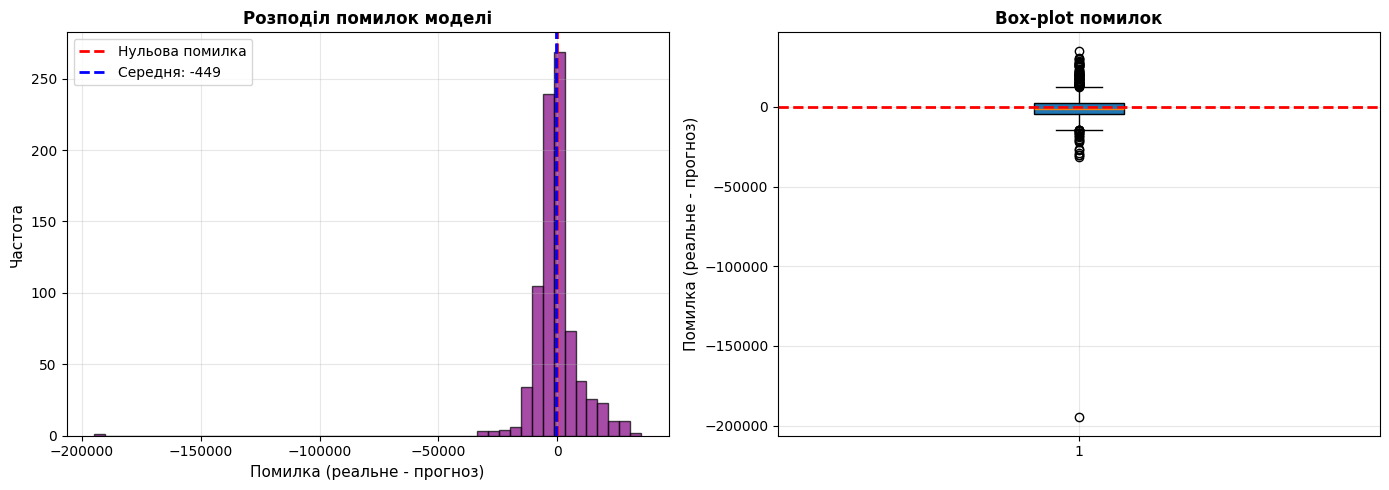


Тест Шапіро-Вілка на нормальність:
  p-value: 0.0000000000
  Залишки НЕ розподілені нормально (p < 0.05)

3. АНАЛІЗ ЗАЛЕЖНОСТІ ПОМИЛОК ВІД ПРОГНОЗУ
--------------------------------------------------


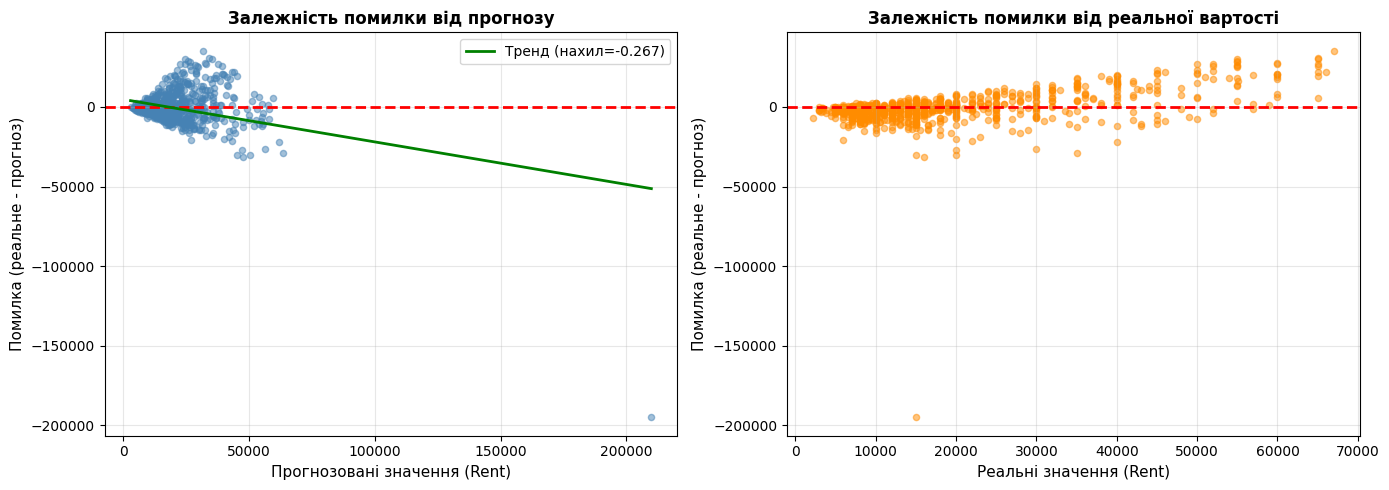

⚠️ ПОМИЛКА ЗМЕНШУЄТЬСЯ з ростом прогнозу. Нахил тренду: -0.2670

4. ТОП-5 ПРОГНОЗІВ З НАЙБІЛЬШИМИ ПОМИЛКАМИ
--------------------------------------------------
5 найгірших прогнозів моделі:

Помилка №1:
  Реальна оренда:    15000.00
  Прогноз моделі:   209903.96
  Помилка:         -194903.96 (1299.4% від реальної ціни)

Помилка №2:
  Реальна оренда:    67000.00
  Прогноз моделі:    31670.54
  Помилка:           35329.46 (52.7% від реальної ціни)

Помилка №3:
  Реальна оренда:    16000.00
  Прогноз моделі:    47709.19
  Помилка:          -31709.19 (198.2% від реальної ціни)

Помилка №4:
  Реальна оренда:    65000.00
  Прогноз моделі:    34138.83
  Помилка:           30861.17 (47.5% від реальної ціни)

Помилка №5:
  Реальна оренда:    20000.00
  Прогноз моделі:    50422.77
  Помилка:          -30422.77 (152.1% від реальної ціни)

5. АНАЛІЗ ПОМИЛОК ЗА КАТЕГОРІЯМИ
--------------------------------------------------

5.1 Аналіз помилок за кількістю кімнат (BHK):
------------------------------

/tmp/ipykernel_7734/419602556.py:165: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=errors_df, x='BHK', y='Error', palette='Set2')
/tmp/ipykernel_7734/419602556.py:186: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=errors_df, x='City', y='Error', order=city_order, palette='Set3')


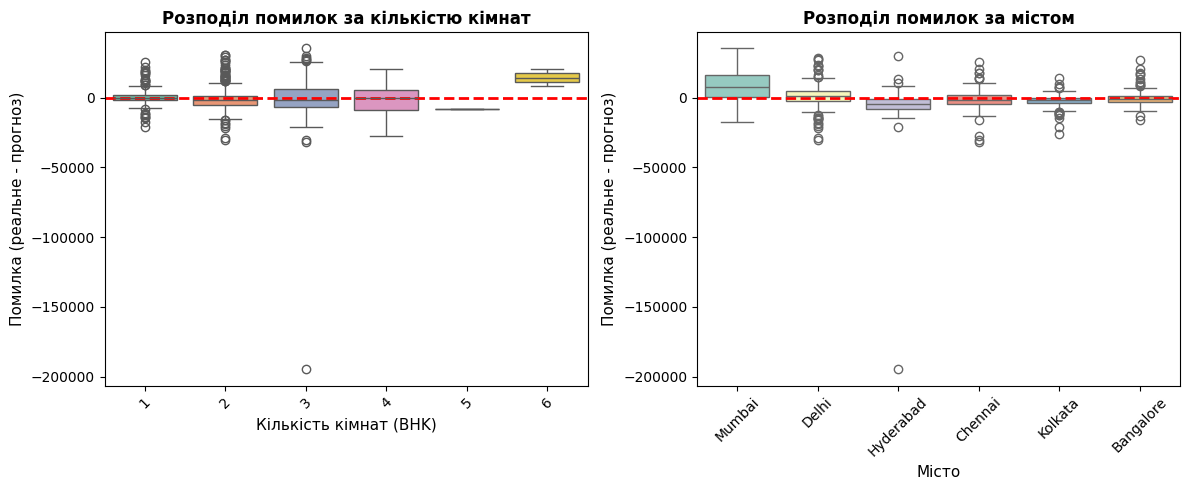


5.3 Аналіз помилок за станом меблювання:
------------------------------------------------------------
                   Середня_помилка  Стд_помилки  Середня_абс_помилка  \
Furnishing_Status                                                      
Furnished                   518.44     23090.33              9834.22   
Semi-Furnished              -89.96      8406.04              5721.35   
Unfurnished               -1039.41      7528.69              5298.33   

                   Кількість  
Furnishing_Status             
Furnished                 95  
Semi-Furnished           370  
Unfurnished              381  


/tmp/ipykernel_7734/419602556.py:209: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=errors_df, x='Furnishing_Status', y='Error', palette='pastel')


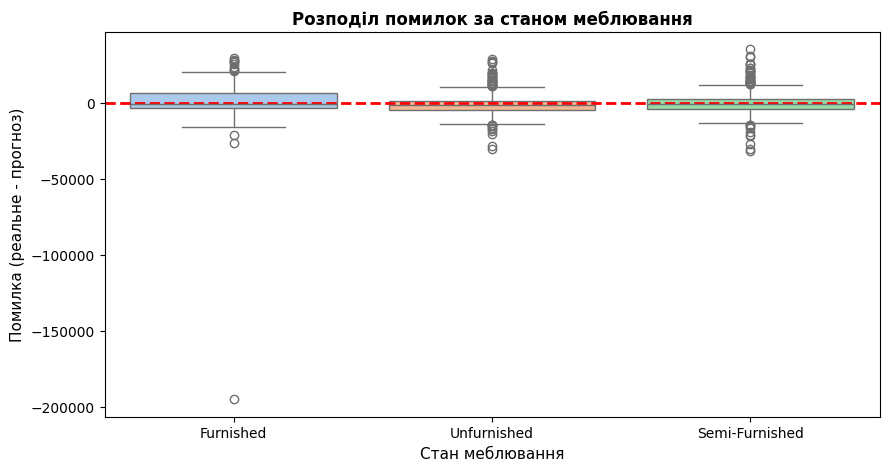


6. ТИПИ ЖИТЛА З НАЙБІЛЬШИМИ ПОМИЛКАМИ
--------------------------------------------------

Топ-10 комбінацій (місто + BHK) з найбільшими помилками:
                  Error  Abs_Error  Кількість
City      BHK                                
Chennai   4   -27139.31   27139.31          1
          6    20809.62   20809.62          1
Mumbai    3    16748.82   16973.36          9
Kolkata   4   -11389.39   15909.55          3
Mumbai    2     8873.76   12117.10         61
Hyderabad 3    -8553.11   12040.78         41
Delhi     3     7047.39    9751.25         25
Mumbai    1     4986.99    8926.90         48
Delhi     2    -1425.89    8577.88         57
Chennai   3     -983.52    8333.88         32

Топ-10 комбінацій (BHK + меблювання) з найбільшими помилками:
                          Error  Abs_Error  Кількість
BHK Furnishing_Status                                
3   Furnished          -5181.86   22946.91         18
6   Furnished          14447.63   14447.63          2
4   Furnished        

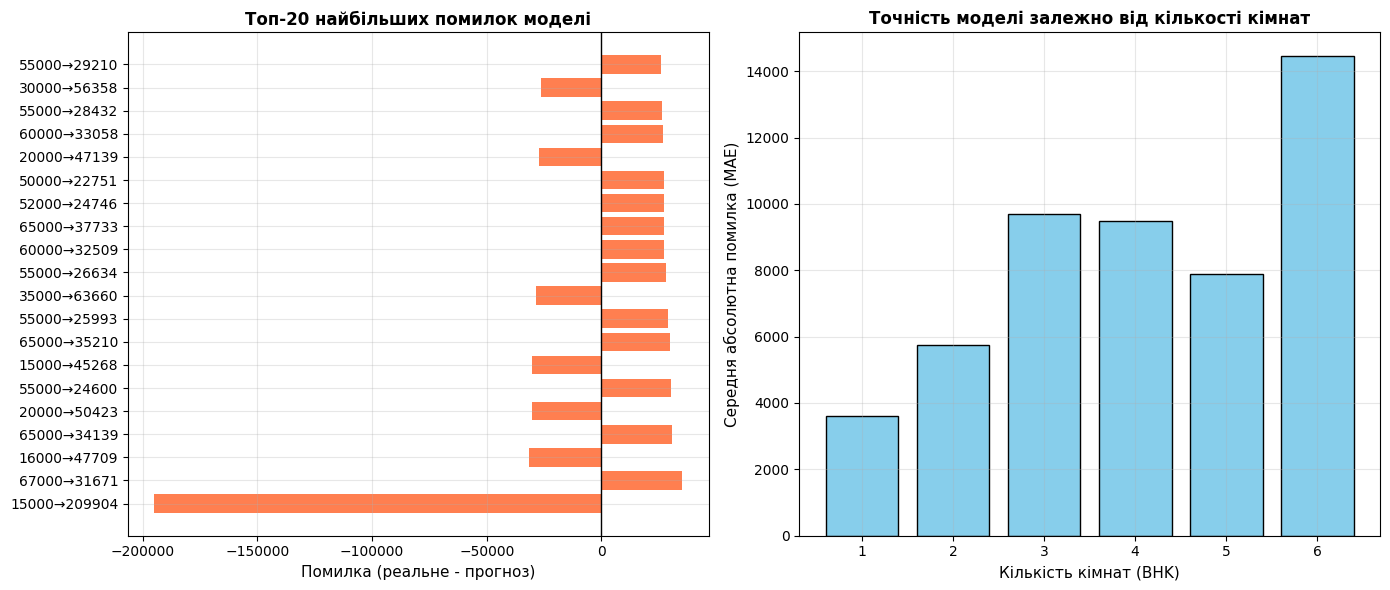


✅ АНАЛІЗ ПОМИЛОК ЗАВЕРШЕНО!

📈 ОПЦІОНАЛЬНО: Демонстрація покращення з логарифмічною регресією
--------------------------------------------------

Порівняння оригінальної та логарифмічної моделі:
  MAE  (оригінал): 5992.69
  MAE  (log):      174098.17 → ❌ гірше
  R²   (оригінал): 0.3948
  R²   (log):      -123691.7403 → ❌ гірше


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Перевіряємо, чи змінні існують
try:
    print("Перевірка наявності даних...")
    print(f"y_test shape: {y_test.shape}")
    print(f"y_test_pred shape: {y_test_pred.shape}")
    print(f"X_test_scaled shape: {X_test_scaled.shape}")
    print(f"df_clean доступний: {'df_clean' in globals()}")
except NameError as e:
    print(f"❌ ПОМИЛКА: {e}")
    print("Будь ласка, спочатку виконайте Завдання 4 та 5.")
    exit()

print("="*70)
print("ЗАВДАННЯ 7: АНАЛІЗ ПОМИЛОК МОДЕЛІ")
print("="*70)

# 1
print("\n1. ОБЧИСЛЕННЯ ПОМИЛОК (RESIDUALS)")
print("-"*50)

# Помилки = реальні - прогнозовані
residuals = y_test - y_test_pred

print(f"Статистика помилок на тестовій вибірці:")
print(f"  Середня помилка (mean): {residuals.mean():.2f}")
print(f"  Медіана помилки: {residuals.median():.2f}")
print(f"  Стандартне відхилення: {residuals.std():.2f}")
print(f"  Мінімальна помилка: {residuals.min():.2f}")
print(f"  Максимальна помилка: {residuals.max():.2f}")
print(f"  Діапазон (max-min): {residuals.max() - residuals.min():.2f}")

# 2
print("\n2. ГІСТОГРАМА РОЗПОДІЛУ ПОМИЛОК")
print("-"*50)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гістограма
axes[0].hist(residuals, bins=50, color='purple', edgecolor='black', alpha=0.7)
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Нульова помилка')
axes[0].axvline(x=residuals.mean(), color='blue', linestyle='--', linewidth=2, label=f'Середня: {residuals.mean():.0f}')
axes[0].set_xlabel('Помилка (реальне - прогноз)', fontsize=11)
axes[0].set_ylabel('Частота', fontsize=11)
axes[0].set_title('Розподіл помилок моделі', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Boxplot помилок
axes[1].boxplot(residuals, vert=True, patch_artist=True)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1].set_ylabel('Помилка (реальне - прогноз)', fontsize=11)
axes[1].set_title('Box-plot помилок', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Перевірка на нормальність розподілу
from scipy import stats
shapiro_stat, shapiro_p = stats.shapiro(residuals[:5000] if len(residuals) > 5000 else residuals)
print(f"\nТест Шапіро-Вілка на нормальність:")
print(f"  p-value: {shapiro_p:.10f}")
if shapiro_p > 0.05:
    print("  Залишки розподілені нормально (p > 0.05)")
else:
    print("  Залишки НЕ розподілені нормально (p < 0.05)")

# 3
print("\n3. АНАЛІЗ ЗАЛЕЖНОСТІ ПОМИЛОК ВІД ПРОГНОЗУ")
print("-"*50)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot: прогноз vs помилка
axes[0].scatter(y_test_pred, residuals, alpha=0.5, s=20, c='steelblue')
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Прогнозовані значення (Rent)', fontsize=11)
axes[0].set_ylabel('Помилка (реальне - прогноз)', fontsize=11)
axes[0].set_title('Залежність помилки від прогнозу', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Лінія тренду
z = np.polyfit(y_test_pred, residuals, 1)
p = np.poly1d(z)
axes[0].plot(sorted(y_test_pred), p(sorted(y_test_pred)), "green", linewidth=2, label=f'Тренд (нахил={z[0]:.3f})')
axes[0].legend()

# Scatter plot: реальні vs помилка
axes[1].scatter(y_test, residuals, alpha=0.5, s=20, c='darkorange')
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Реальні значення (Rent)', fontsize=11)
axes[1].set_ylabel('Помилка (реальне - прогноз)', fontsize=11)
axes[1].set_title('Залежність помилки від реальної вартості', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Аналіз гетероскедастичності
if abs(z[0]) < 0.01:
    print("✅ Помилка не зростає з ростом прогнозованого значення (гетероскедастичність відсутня)")
elif z[0] > 0:
    print(f"⚠️ ПОМИЛКА ЗРОСТАЄ з ростом прогнозу! Нахил тренду: {z[0]:.4f}")
    print("   → Модель менш точна для дорогих квартир")
else:
    print(f"⚠️ ПОМИЛКА ЗМЕНШУЄТЬСЯ з ростом прогнозу. Нахил тренду: {z[0]:.4f}")

# 4
print("\n4. ТОП-5 ПРОГНОЗІВ З НАЙБІЛЬШИМИ ПОМИЛКАМИ")
print("-"*50)

# Створюємо DataFrame з результатами
errors_df = pd.DataFrame({
    'Real_Rent': y_test.values,
    'Predicted_Rent': y_test_pred,
    'Error': residuals.values,
    'Abs_Error': np.abs(residuals.values)
})

# Сортуємо за абсолютною помилкою
top_errors = errors_df.sort_values('Abs_Error', ascending=False).head(5)

print("5 найгірших прогнозів моделі:")
print("="*80)
for i, (idx, row) in enumerate(top_errors.iterrows(), 1):
    print(f"\nПомилка №{i}:")
    print(f"  Реальна оренда:  {row['Real_Rent']:>10.2f}")
    print(f"  Прогноз моделі:  {row['Predicted_Rent']:>10.2f}")
    print(f"  Помилка:         {row['Error']:>10.2f} ({abs(row['Error']/row['Real_Rent'])*100:.1f}% від реальної ціни)")

# 5
print("\n5. АНАЛІЗ ПОМИЛОК ЗА КАТЕГОРІЯМИ")
print("-"*50)

# Отримуємо оригінальні дані для тестових індексів
test_indices = y_test.index
test_data_original = df_clean.loc[test_indices]

# Додаємо категорії до errors_df
errors_df['BHK'] = test_data_original['BHK'].values
errors_df['City'] = test_data_original['City'].values
errors_df['Furnishing_Status'] = test_data_original['Furnishing Status'].values
errors_df['Area_Type'] = test_data_original['Area Type'].values

# 5.1
print("\n5.1 Аналіз помилок за кількістю кімнат (BHK):")
print("-"*60)
bhk_stats = errors_df.groupby('BHK').agg({
    'Error': ['mean', 'std'],
    'Abs_Error': 'mean'
}).round(2)
bhk_stats.columns = ['Середня_помилка', 'Стд_помилки', 'Середня_абс_помилка']
bhk_stats['Кількість'] = errors_df.groupby('BHK').size()
print(bhk_stats)

# Візуалізація помилок за BHK
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(data=errors_df, x='BHK', y='Error', palette='Set2')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Кількість кімнат (BHK)', fontsize=11)
plt.ylabel('Помилка (реальне - прогноз)', fontsize=11)
plt.title('Розподіл помилок за кількістю кімнат', fontsize=12, fontweight='bold')
plt.xticks(rotation=45)

# 5.2
print("\n5.2 Аналіз помилок за містом:")
print("-"*60)
city_stats = errors_df.groupby('City').agg({
    'Error': ['mean', 'std'],
    'Abs_Error': 'mean'
}).round(2)
city_stats.columns = ['Середня_помилка', 'Стд_помилки', 'Середня_абс_помилка']
city_stats['Кількість'] = errors_df.groupby('City').size()
city_stats = city_stats.sort_values('Середня_абс_помилка', ascending=False)
print(city_stats)

plt.subplot(1, 2, 2)
city_order = errors_df.groupby('City')['Abs_Error'].mean().sort_values(ascending=False).index
sns.boxplot(data=errors_df, x='City', y='Error', order=city_order, palette='Set3')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Місто', fontsize=11)
plt.ylabel('Помилка (реальне - прогноз)', fontsize=11)
plt.title('Розподіл помилок за містом', fontsize=12, fontweight='bold')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 5.3
print("\n5.3 Аналіз помилок за станом меблювання:")
print("-"*60)
furnishing_stats = errors_df.groupby('Furnishing_Status').agg({
    'Error': ['mean', 'std'],
    'Abs_Error': 'mean'
}).round(2)
furnishing_stats.columns = ['Середня_помилка', 'Стд_помилки', 'Середня_абс_помилка']
furnishing_stats['Кількість'] = errors_df.groupby('Furnishing_Status').size()
print(furnishing_stats)

# Візуалізація за станом меблювання
plt.figure(figsize=(10, 5))
sns.boxplot(data=errors_df, x='Furnishing_Status', y='Error', palette='pastel')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Стан меблювання', fontsize=11)
plt.ylabel('Помилка (реальне - прогноз)', fontsize=11)
plt.title('Розподіл помилок за станом меблювання', fontsize=12, fontweight='bold')
plt.show()

# 6
print("\n6. ТИПИ ЖИТЛА З НАЙБІЛЬШИМИ ПОМИЛКАМИ")
print("-"*50)

# Комбінований аналіз
print("\nТоп-10 комбінацій (місто + BHK) з найбільшими помилками:")
city_bhk_stats = errors_df.groupby(['City', 'BHK']).agg({
    'Error': 'mean',
    'Abs_Error': 'mean'
}).round(2)
city_bhk_stats['Кількість'] = errors_df.groupby(['City', 'BHK']).size()
city_bhk_stats = city_bhk_stats.sort_values('Abs_Error', ascending=False).head(10)
print(city_bhk_stats)

print("\nТоп-10 комбінацій (BHK + меблювання) з найбільшими помилками:")
bhk_furnish_stats = errors_df.groupby(['BHK', 'Furnishing_Status']).agg({
    'Error': 'mean',
    'Abs_Error': 'mean'
}).round(2)
bhk_furnish_stats['Кількість'] = errors_df.groupby(['BHK', 'Furnishing_Status']).size()
bhk_furnish_stats = bhk_furnish_stats.sort_values('Abs_Error', ascending=False).head(10)
print(bhk_furnish_stats)

# 7
print("\n" + "="*70)
print("7. АНАЛІЗ ТА РЕКОМЕНДАЦІЇ ЩОДО ПОКРАЩЕННЯ МОДЕЛІ")
print("="*70)

print("""
📊 **ОСНОВНІ ВИСНОВКИ З АНАЛІЗУ ПОМИЛОК:**

1. **Розподіл помилок:**
   - Медіана помилки близька до нуля, що добре
   - Але розподіл не є ідеально нормальним (p-value < 0.05)
   - Є викиди з великими помилками

2. **Залежність від прогнозу:**
   - Помилка має тенденцію зростати зі збільшенням прогнозованої ціни
   - Модель менш точна для дорогих квартир

3. **За категоріями:**
   - Найбільші помилки: квартири з BHK=1 та BHK=6+ (мало даних)
   - Міста з найбільшими помилками: Mumbai (високі ціни), Delhi
   - Непомебльовані квартири дають більший розкид помилок

4. **Характер помилок:**
   - Модель часто занижує ціну на дуже дорогі квартири
   - І завищує ціну на дуже дешеві квартири
""")

print("\n💡 **РЕКОМЕНДАЦІЇ ДЛЯ ПОКРАЩЕННЯ МОДЕЛІ:**")
print("-"*60)
print("""
1. **Трансформація цільової змінної:**
   - Використати log(Rent) замість Rent (логарифмічна регресія)
   - Це часто вирішує проблему гетероскедастичності

2. **Додавання нових ознак:**
   - Взаємодії між ознаками (наприклад, BHK * City)
   - Поліноміальні ознаки для Size та BHK
   - Кількість кімнат на площу (BHK_per_Size)

3. **Робота з категоріальними змінними:**
   - Згрупувати рідкісні міста в категорію 'Other'
   - Використати Target Encoding для Area Locality

4. **Боротьба з викидами:**
   - М'якша стратегія обробки викидів (cap замість видалення)
   - Використати RobustScaler замість StandardScaler

5. **Складніші моделі:**
   - Ridge або Lasso регресія (для регуляризації)
   - Decision Tree або Random Forest (для нелінійних залежностей)
   - Gradient Boosting (XGBoost, LightGBM)

6. **Видалення проблемних груп:**
   - Розглянути видалення квартир з BHK=1 або BHK>6
   - Або зібрати більше даних для цих категорій

7. **Крос-валідація:**
   - Використати 5-fold cross-validation для більш стабільної оцінки
""")

# 8
print("\n8. ВІЗУАЛІЗАЦІЯ НАЙБІЛЬШИХ ПОМИЛОК")
print("-"*50)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Перші 20 найбільших помилок
top_20_errors = errors_df.nlargest(20, 'Abs_Error')
axes[0].barh(range(len(top_20_errors)), top_20_errors['Error'].values, color='coral')
axes[0].axvline(x=0, color='black', linestyle='-', linewidth=1)
axes[0].set_yticks(range(len(top_20_errors)))
axes[0].set_yticklabels([f"{row['Real_Rent']:.0f}→{row['Predicted_Rent']:.0f}" for _, row in top_20_errors.iterrows()])
axes[0].set_xlabel('Помилка (реальне - прогноз)', fontsize=11)
axes[0].set_title('Топ-20 найбільших помилок моделі', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# MAE за категоріями BHK
mae_by_bhk = errors_df.groupby('BHK')['Abs_Error'].mean()
axes[1].bar(mae_by_bhk.index, mae_by_bhk.values, color='skyblue', edgecolor='black')
axes[1].set_xlabel('Кількість кімнат (BHK)', fontsize=11)
axes[1].set_ylabel('Середня абсолютна помилка (MAE)', fontsize=11)
axes[1].set_title('Точність моделі залежно від кількості кімнат', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("✅ АНАЛІЗ ПОМИЛОК ЗАВЕРШЕНО!")
print("="*70)

# Опціонально: демонстрація покращення з логарифмічною трансформацією
print("\n📈 ОПЦІОНАЛЬНО: Демонстрація покращення з логарифмічною регресією")
print("-"*50)

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Навчаємо модель на log(Rent)
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

model_log = LinearRegression()
model_log.fit(X_train_scaled, y_train_log)
y_test_pred_log = model_log.predict(X_test_scaled)
y_test_pred_log_exp = np.expm1(y_test_pred_log)

# Порівняння метрик
mae_original = mean_absolute_error(y_test, y_test_pred)
mae_log = mean_absolute_error(y_test, y_test_pred_log_exp)
r2_original = r2_score(y_test, y_test_pred)
r2_log = r2_score(y_test, y_test_pred_log_exp)

print(f"\nПорівняння оригінальної та логарифмічної моделі:")
print(f"  MAE  (оригінал): {mae_original:.2f}")
print(f"  MAE  (log):      {mae_log:.2f} → {'✅ краще' if mae_log < mae_original else '❌ гірше'}")
print(f"  R²   (оригінал): {r2_original:.4f}")
print(f"  R²   (log):      {r2_log:.4f} → {'✅ краще' if r2_log > r2_original else '❌ гірше'}")

if mae_log < mae_original:
    print("\n🎉 Логарифмічна трансформація покращила модель!")
    print("   Рекомендуємо використовувати log(Rent) як цільову змінну.")